In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [7]:
sns.set_theme(style='whitegrid')

In [8]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
data['TotalCharges'] =  pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
phoneService_yes = data[data['PhoneService'] == 'Yes'].copy()

phoneService_yes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [14]:
# Converting Churn to binary allows for mathematical operations (like mean) to represent the Churn Rate directly.
churn_map = {'Yes': 1, 'No': 0}

data['Churn_Binary'] = data['Churn'].map(churn_map)

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [15]:
contract_churn = data.groupby('Contract', as_index=False)['Churn_Binary'].mean()

contract_churn['Churn_Binary'] = (contract_churn['Churn_Binary'] * 100).round(2)

contract_churn = contract_churn.rename(columns={'Churn_Binary': 'Churn_%'})

contract_churn

,Contract,Churn_%
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


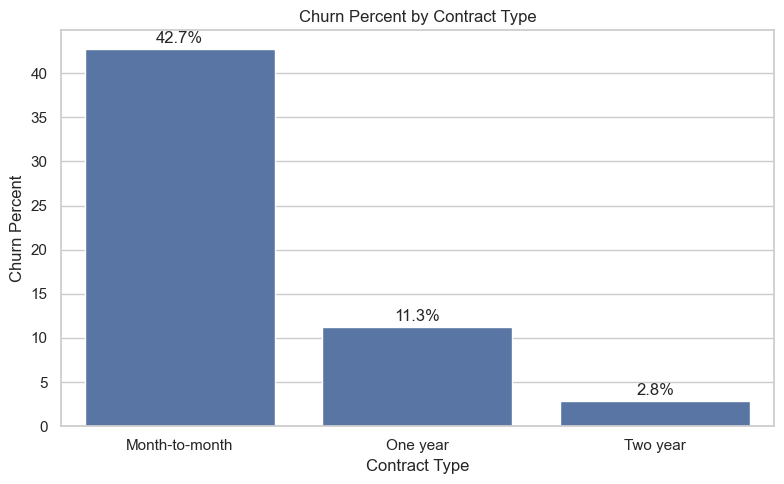

In [16]:
plt.figure(figsize=(8,5))

ax = sns.barplot(data=contract_churn, x='Contract', y='Churn_%')

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=2)

plt.title('Churn Percent by Contract Type')
plt.ylabel('Churn Percent')
plt.xlabel('Contract Type')

plt.tight_layout()
plt.show()

In [17]:
monthToMonth_Contract = data[data['Contract'] == 'Month-to-month'].copy()

monthToMonth_Contract

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No,0
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.10,No,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0


In [18]:
tenure_churn = monthToMonth_Contract.groupby('tenure', as_index=False)['Churn_Binary'].mean()

tenure_churn = tenure_churn.rename(columns={'Churn_Binary': 'Churn_%'})
tenure_churn['Churn_%'] = tenure_churn['Churn_%'] * 100

tenure_churn

,tenure,Churn_%
0,1,62.913907
1,2,52.608696
2,3,49.214660
3,4,49.696970
4,5,49.218750
...,...,...
67,68,30.000000
68,69,50.000000
69,70,25.000000
70,71,20.000000


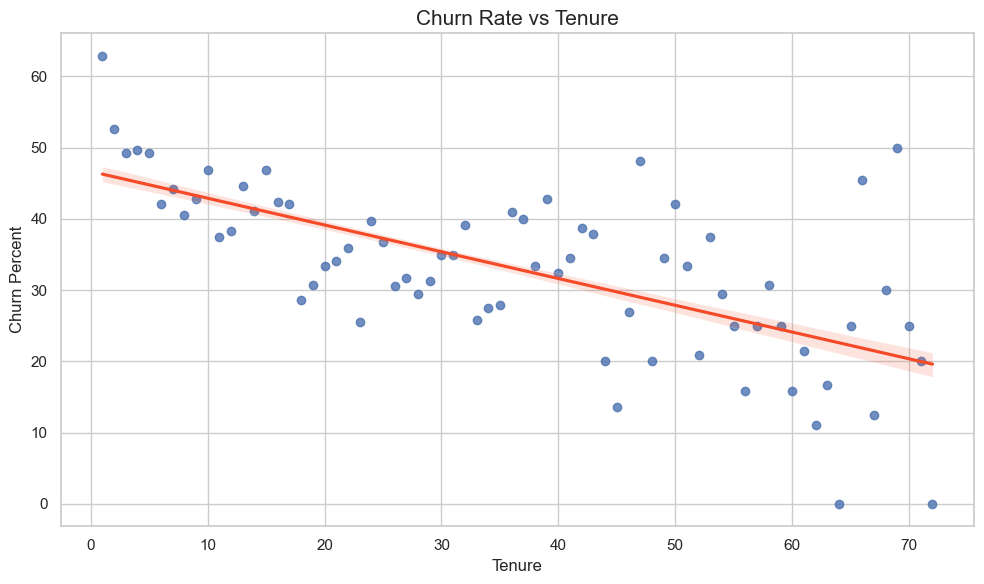

In [19]:
# Using a regression plot to smooth out the noise and visualize the long-term trend between loyalty and churn risk.
plt.figure(figsize=(10,6))

sns.regplot(data=tenure_churn, x='tenure', y='Churn_%', ci=45, line_kws={'color': '#F54927'})

plt.ylabel('Churn Percent')
plt.xlabel('Tenure')
plt.title('Churn Rate vs Tenure', fontsize=15)

plt.tight_layout()
plt.show()

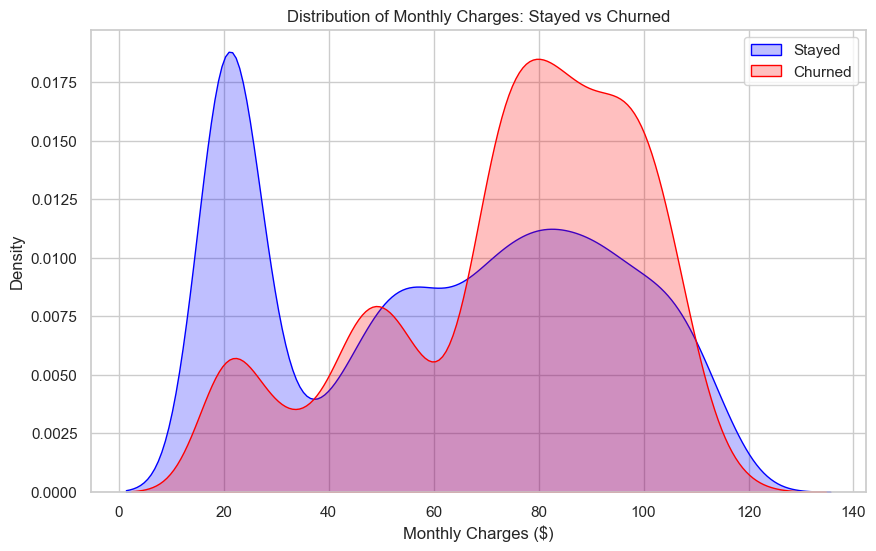

In [20]:
plt.figure(figsize=(10,6))

stayed = data[data['Churn'] == 'No']['MonthlyCharges']

ax = sns.kdeplot(data=stayed, fill=True, color='blue', label='Stayed')

churned = data[data['Churn'] == 'Yes']['MonthlyCharges']

ax1 = sns.kdeplot(data=churned, fill=True, color='red', label='Churned')

plt.title('Distribution of Monthly Charges: Stayed vs Churned')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.legend()
plt.show()


In [21]:
transition_zone = data[(data['MonthlyCharges'] >= 55) & (data['MonthlyCharges'] <= 73)]

transition_zone.groupby('InternetService')['Churn_Binary'].mean() * 100

InternetService
DSL            13.454545
Fiber optic    58.436214
Name: Churn_Binary, dtype: float64

In [22]:
transition_zone['InternetService'].value_counts()

InternetService
DSL            825
Fiber optic    243
Name: count, dtype: int64

In [23]:
fiber_only = data[data['InternetService'] == 'Fiber optic'].copy()

fiber_only.groupby('OnlineSecurity')['Churn_Binary'].mean() * 100

OnlineSecurity
No     49.357554
Yes    21.811681
Name: Churn_Binary, dtype: float64

In [24]:
fiber_only.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,0
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.10,No,0


In [25]:
# Focusing on this price bracket to investigate the 'Value Gap' where Fiber Optic and DSL prices overlap but churn rates diverge.
high_churn = data[(data['MonthlyCharges'] > 63) & (data['MonthlyCharges'] < 110)]

high_churn_df = high_churn.groupby(['InternetService', 'OnlineSecurity'], as_index=False)['Churn_Binary'].mean()

high_churn_df['Churn_Binary'] = high_churn_df['Churn_Binary'] * 100

high_churn_df = high_churn_df.sort_values('Churn_Binary', ascending=False)



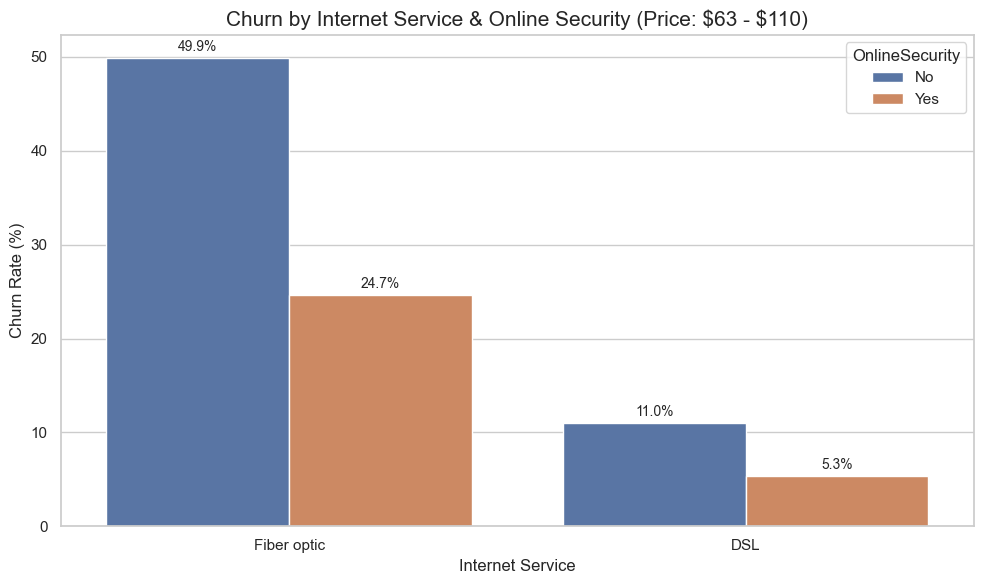

In [26]:
plt.figure(figsize=(10,6))

ax = sns.barplot(data=high_churn_df, x='InternetService', y='Churn_Binary', hue='OnlineSecurity')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

ax.set_title(r'Churn by Internet Service & Online Security (Price: \$63 - \$110)', fontsize=15)
ax.set_xlabel('Internet Service', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)

plt.tight_layout()
plt.show()